# Analysis of Gameplay Strategies and Patterns in Chess Games

## 1. Background and Motivation

The game of chess is an incredibly fascinating, yet deceptively simple, game. With only six unique pieces, each constrained to a number of legal moves on a small 8x8 grid, the game may seem trivial. Yet, chess remains infinitely complex, boasting an estimated 10^120 unique games. This extensive replayability and strategy behind the game has allowed chess to withstand the test of time, being played for over a thousand years all the way into the digital age. And this is where our project motivation stems from: chess in the modern day. Because the game is so popular, there are multiple robust datasets of online chess games publicly available. These datasets provide everything from the game winner, to the moves that were made, to the rating (ELO) of the players. Having this much accessible data would allow for extensive statistical analysis, revealing new trends in the digital era or retention of old reliable strategies to this day. Additionally, the implementation of chess engines, such as Stockfish, may prove interesting in effectively analyzing strategies and game state evaluations. We aim to study a dataset of games from the public chess platform Lichess in the hopes of discovering such patterns.

## 2. Project Objectives

The overarching goal of this project is to see whether data science methods are useful in analyzing chess game data. Chess is an incredibly complex game and game analysis at a high level boils down to brute mathematical analysis of the game state. We seek to analyze chess with a large data approach. We seek to draw conclusions about player tendencies, playstyles, and other attributes based on data. Not just finding the "best" way to play chess. Research questions and goals became more clear throughout the process of working with the data. The final set of research questions is as follows:

##### 2.1. Can we utilize patterns in the data to differentiate between the gameplay style of experienced players vs inexperienced players?

##### 2.2. What correlations or other predictions can be identified based on game data?

##### 2.3. Can we use machine learning to predict the rating of a player based purely on a list of moves?

In the previous milestone submission, we posed a large number of questions research questions. Those questions were helpful in leading us to the list of three seen above. These questions are more focused and keep the project in an acheivable scope.

## 3. Ethical Concerns

From our stakeholder analysis in our proposal, we identified four different stakeholders in our project. The following list outlines these stakeholders and the harm mitigation steps taken to reduce the harm of our project.

#### 3.1. Lichess players

- We are directly analyzing this group's data.
- It is possible that conclusions drawn from this dataset could harm players. For instance, if a specific game is analyzed, bad actors could cyberbully the players in that game for their playstyle.
  - To prevent this from happening, we never analyze a singular game of chess. Data is processed and aggregated into tables, plots, and diagrams
  - Furthermore, harm is mitigated by dropping the player names/ids from the dataframe. This means that no player information will be exposed in this project.

#### 3.3. Lichess.org

- We are using Lichess.org's data for analysis.
- The harm that could come about from this is misrepresenting the community of Lichess or using their data in ways that they do not approve.
  - For the analysis done for this project, we are well within the guidelines for fair use of their data.
  - Lichess.org states: "Database exports are released under the Creative Commons CC0 license. Use them for research, commercial purpose, publication, anything you like. You can download, modify and redistribute them, without asking for permission."

#### 3.4. Larger Chess Player Community

- These stakeholders could use and study the models developed in this project in order to sharpen their game.
- If incorrect conclusions are drawn from this dataset, it could cause players to adopt unhelpful strategies in their gameplay.
  - Mitigation of this can be seen in section 5.
  - We make it clear that we are not experts, and the conclusions drawn are not necessarily 100% accurate.
- It is possible that the conclusions drawn from this project could be used to assign stereotypes to players of different ELOs.
  - In our language, we never use ELO to say anything about individual or groups personally. Our verbiage makes it clear that we are only analyzing chess gameplay and not IQ/intelligence of players.
  - The aim of this project is to analyze chess games for the purpose of exploration. Conclusions that may imply certain stereotypes are not made in bad faith.

#### 3.5. Chess Coaches and Tournament Players (Competitive Chess)

- This group could study the models and analysis done in this project to become better at either coaching or playing chess.
- If incorrect conclusions are drawn from this dataset, players or coaches may adopt unhelpful strategies in their gameplay and teaching. This risk level is especially concerning for this group because they have made a career out of chess.
  - Risk mitigation of this is stated in disclaimer in section 4.
  - We make it clear that we are not experts, and the conclusions drawn are not necessarily 100% accurate.

## 4. Disclaimer

The team members on this project are by no means chess experts. We are casual enjoyers of the game. With that said, the conclusions drawn from this dataset may be flawed due to lack of expertise. All the code used to analyze, plot, and develop models is available in this notebook (and external modules clearly outlined). This transparency allows for an observer to draw their own conclusions about the validity of our conclusions.

## 5. Data Acquisition and Cleaning

#### 5.2. High Level Description of Methods

More detail of the analysis steps can be drawn from the well commented code in this notebook, but following is an overview of the steps taken to process, analyze, and plot the data.

Data Acquisition

- Data was downloaded from Kaggle. This is the link to the dataset used: https://www.kaggle.com/datasets/datasnaek/chess/data
- Downloaded as a CSV
- Dataset includes: - Game ID; - Rated (T/F); - Start Time; - End Time; - Number of Turns; - Game Status; - Winner; - Time Increment; - White Player ID; - White Player Rating; - Black Player ID; - Black Player Rating; - All Moves in Standard Chess Notation; - Opening Eco (Standardised Code for any given opening, list here); - Opening Name; - Opening Ply (Number of moves in the opening phase)

Data Cleaning

- Player and game ids were dropped to comply with section 3.1.
- Non-rated games were dropped for rating analysis.
- Categorical data was assigned to numeric values:
  - Winner data was assigned to -1, 0, and 1 for black wins, draw, and white wins respectively.
  - Game ending data was assigned to 0, 1, 2, 3 for resigns, mates, draws, and timeouts respectively.
  - Moves were separated into arrays.
  - Game rating data was added as average ELO of both players.

Data Processing

- This project required a high degree of data processing and wrangling
- After doing exploratory analysis, we found that the current state of the data was insufficient to draw interesting conclusions
- We knew that we could leverage the "moves" data, so we found used that in data processing
- We did two types of data processing:
  - Stockfish centipawn calculation (see \_\_\_)
  - Board analysis (see \_\_\_)


#### 5.3 Cleaning


In [1]:
# Import Libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import chess
import chess.engine

import multiprocessing as mp
from pathos.multiprocessing import ProcessingPool as Pool

import statsmodels.formula.api as sm
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler

**Note for Instructors and TAs**

- To properly run this project, you will need to install the following:
  - Stockfish. Find instructions here: https://stockfishchess.org/download/
  - Run the following commands to set up the environment:

```bash
conda create -n chess python-3.11
conda activate chess
pip install pandas
pip install matplotlib
pip install seaborn
pip install chess
pip install tensorflow
pip install flask
pip install pathos
```


In [2]:
# Import data and observe shape and columns
chess_data_raw = pd.read_csv("data/games.csv")
print(chess_data_raw.shape)
print(chess_data_raw.columns)
chess_data_raw.head()

(20058, 16)
Index(['id', 'rated', 'created_at', 'last_move_at', 'turns', 'victory_status',
       'winner', 'increment_code', 'white_id', 'white_rating', 'black_id',
       'black_rating', 'moves', 'opening_eco', 'opening_name', 'opening_ply'],
      dtype='object')


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


In [3]:
chess_data = chess_data_raw.drop(columns=["id", "white_id", "black_id"])
chess_data = chess_data.dropna()

# Drop all non-rated games for doing rating analysis
print(len(chess_data))
chess_data = chess_data[chess_data["rated"] == True]
# Remove rated, created at, and last move at columns
chess_data = chess_data.drop(["rated","created_at","last_move_at"],axis=1)
# Map winner column
chess_data["winner"] = chess_data["winner"].map({"black": -1, "white": 1}).fillna(0)
# Map victory column
chess_data["victory_status"] = chess_data["victory_status"].map({"resign": 0, "mate": 1,"draw": 2, "outoftime": 3})
# Convert moves column to array of moves
chess_data["moves"] = chess_data["moves"].str.split(" ")
# Assume average game rating (averge of player ratings)
chess_data["game_rating"] = (chess_data["white_rating"] + chess_data["black_rating"]) / 2
# Drop games less than 4
chess_data = chess_data[chess_data['turns'] >= 4]

print(len(chess_data))
# use cut to separate by equal ranking block sizes
# use qcut if want bins to have equal amounts in each block
chess_data["rating_bucket"] = pd.cut(
    chess_data["game_rating"],
    bins=3,
    labels=["low", "medium", "high"]
)

chess_data.head()

20058
15943


,turns,victory_status,winner,increment_code,white_rating,black_rating,moves,opening_eco,opening_name,opening_ply,game_rating,rating_bucket
1,16,0,-1.0,5+10,1322,1261,"[d4, Nc6, e4, e5, f4, f6, dxe5, fxe5, fxe5, Nx...",B00,Nimzowitsch Defense: Kennedy Variation,4,1291.5,low
2,61,1,1.0,5+10,1496,1500,"[e4, e5, d3, d6, Be3, c6, Be2, b5, Nd2, a5, a4...",C20,King's Pawn Game: Leonardis Variation,3,1498.0,medium
3,61,1,1.0,20+0,1439,1454,"[d4, d5, Nf3, Bf5, Nc3, Nf6, Bf4, Ng4, e3, Nc6...",D02,Queen's Pawn Game: Zukertort Variation,3,1446.5,medium
4,95,1,1.0,30+3,1523,1469,"[e4, e5, Nf3, d6, d4, Nc6, d5, Nb4, a3, Na6, N...",C41,Philidor Defense,5,1496.0,medium
6,33,0,1.0,10+0,1520,1423,"[d4, d5, e4, dxe4, Nc3, Nf6, f3, exf3, Nxf3, N...",D00,Blackmar-Diemer Gambit: Pietrowsky Defense,10,1471.5,medium


## 6. Exploratory Analysis


Players of Black Ratings ---------------
Mean: 1596.395659537101
Median: 1576.0

Players of White Ratings ---------------
Mean: 1599.9094900583327
Median: 1579.0

All Player Ratings ---------------
Mean: 1598.1525747977169
Median: 1577.0



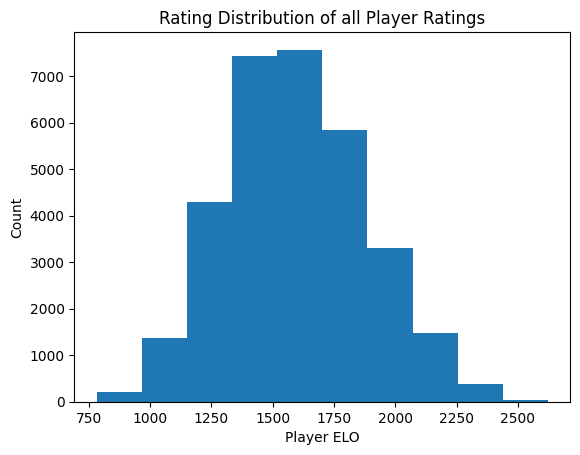

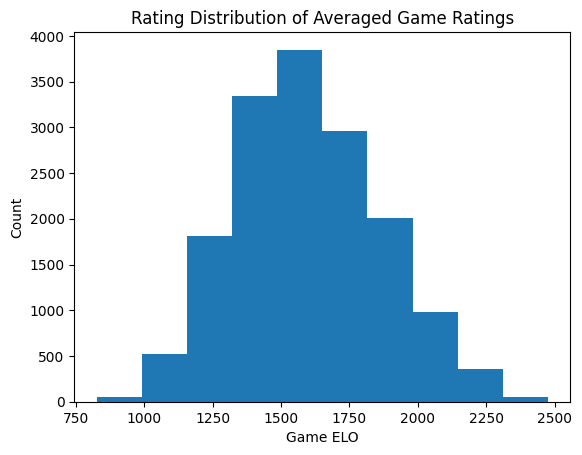

In [4]:
# Preliminary Data
print("Players of Black Ratings ---------------")
print("Mean:", chess_data["black_rating"].mean())
print("Median:", chess_data["black_rating"].median())
print()
print("Players of White Ratings ---------------")
print("Mean:", chess_data["white_rating"].mean())
print("Median:", chess_data["white_rating"].median())
print()
# Make array with every player (both black or white)
all_players = pd.concat([chess_data['white_rating'], chess_data['black_rating']], ignore_index=True)
print("All Player Ratings ---------------")
print("Mean:", all_players.mean())
print("Median:", all_players.median())
print()

# Visualization of rating distribution
plt.hist(all_players)
plt.title("Rating Distribution of all Player Ratings")
plt.xlabel("Player ELO")
plt.ylabel("Count")
plt.show()
plt.hist(chess_data['game_rating'])
plt.title("Rating Distribution of Averaged Game Ratings")
plt.xlabel("Game ELO")
plt.ylabel("Count")
plt.show()

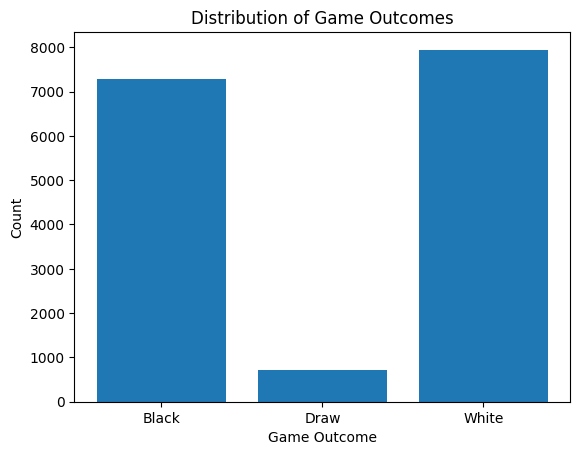

In [5]:
# Count occurrences of each outcome
counts = chess_data['winner'].value_counts().sort_index()

# Ensure order: Black (-1), Draw (0), White (1)
counts = counts.reindex([-1, 0, 1])

# Map labels
labels = ['Black', 'Draw', 'White']

# Plot
plt.figure()
plt.bar(labels, counts)
plt.title('Distribution of Game Outcomes')
plt.xlabel('Game Outcome')
plt.ylabel('Count')
plt.show()

<Axes: ylabel='Count'>

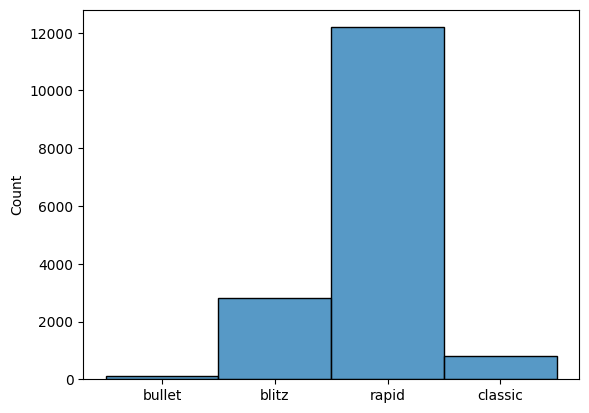

In [36]:
# Set Game Type
#Bullet – under 3 minutes
#Blitz – 3 to 8 minutes
#Rapid – 8 to 25 minutes
#Classical – 25+ minutes
chess_data['game_type'] = [int(_.split('+')[0]) for _ in chess_data['increment_code']]
type_map = {}
for i in range(0,chess_data['game_type'].max()+1):
    if i <= 3:
        type_map[i] = 0
    elif i <= 8:
        type_map[i] = 1
    elif i<= 25:
        type_map[i] = 2
    else:
        type_map[i] = 3
chess_data['game_type'] = chess_data['game_type'].map(type_map)
sns.histplot(pd.Categorical(chess_data['game_type'].map({0:'bullet',1:'blitz',2:'rapid',3:'classic'}),categories=['bullet','blitz','rapid','classic'],ordered=True))

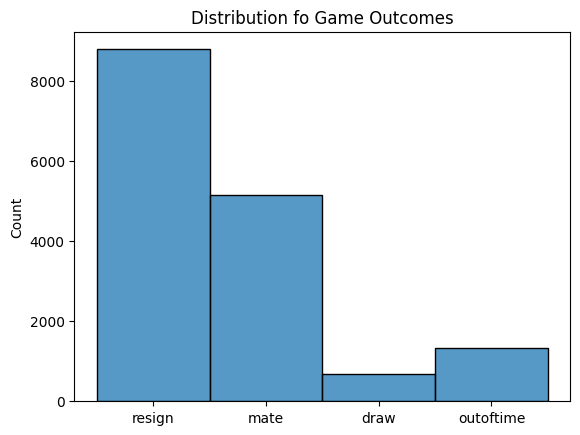

In [39]:
# Game outcome distribution
sns.histplot(pd.Categorical(chess_data['victory_status'].map({0:'resign',1:'mate',2:'draw',3:'outoftime'}),categories=['resign','mate','draw','outoftime'],ordered=True))
plt.title('Distribution fo Game Outcomes')
plt.show()

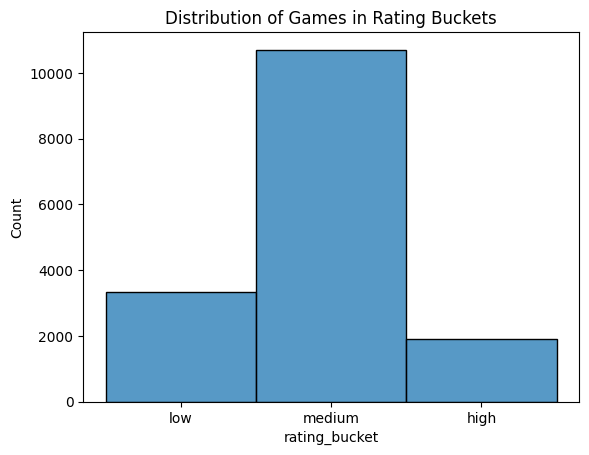

In [48]:
sns.histplot(chess_data['rating_bucket'])
plt.title('Distribution of Games in Rating Buckets')
plt.show()

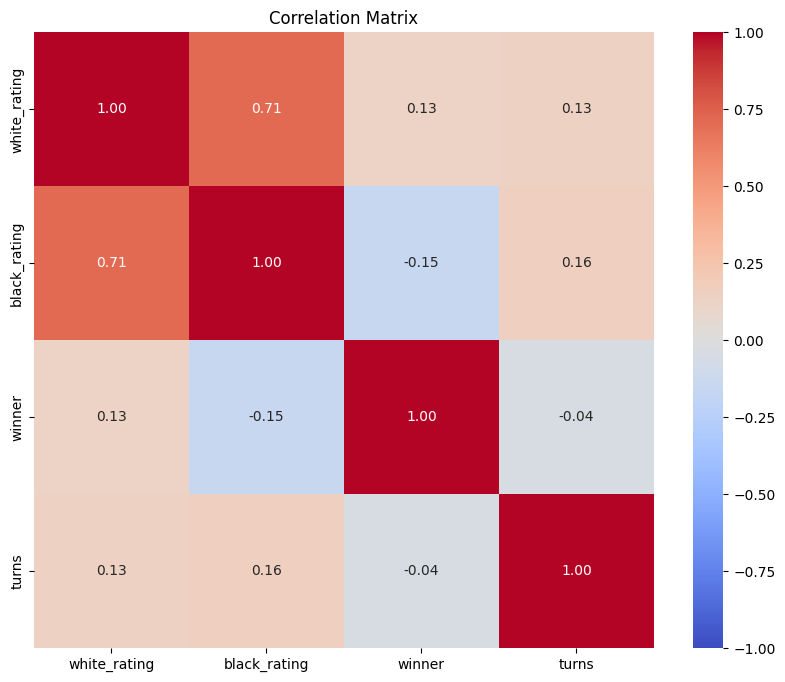

In [6]:
# Preliminary correlation matrix
chess_corr_data = chess_data[["white_rating", "black_rating", "winner", "turns"]]

corr_matrix = chess_corr_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmax=1, vmin=-1)
plt.title("Correlation Matrix")
plt.show()

#### 6.1. Chess Opening Analysis

This sections provides an analysis on possibly the most well-documented part of the game of chess: the openings. ELO blocks were used to separate opening analyses by rating.

##### Methods

Opening ecos were studied for each ELO group. Data acquired on each opening at each rating include: mean black/white rating, standard deviation of black/white rating, game winner, and amount of times opening was played. Data was visualized in histograms and scatterplots.

##### Results

The average amount of turns per game was centered at ~60. Player ELO did not appear to have significant impact on game length. The most popular openings over all players was found to be A00, C00, and D00. However, this popularity varied slightly by ELO category. At lower ELOs, the most popular openings were A00, C20, and B01. At medium ELOs, the most popular openings were C00, A00, and C41. At higher ELOs, the most popular openings were B01, C00, and D02. This difference may suggest patterns in what openings are most effective at certain ratings, whether by efficacy or by complexity. Further analysis is required.


In [7]:
# Get most popular opening for each rating block
def getOpeningPopularity(block,n):
      if block == "all":
            sample = chess_data
      else:
            sample = chess_data[chess_data["rating_bucket"]==block]
      # Get stats of opening
      eco_stats = sample.groupby("opening_eco").agg(
            white_rating_mean=("white_rating", "mean"),
            white_rating_std=("white_rating", "std"),
            black_rating_mean=("black_rating", "mean"),
            black_rating_std=("black_rating", "std"),
            count=("opening_eco", "size"),
            winner=("winner", "mean"),
      )
      most_popular = eco_stats.nlargest(n, "count")
      least_popular = eco_stats[eco_stats["count"] == 1]
      print("\n==========\n"
            f"Most Popular Opening for {block.capitalize()} Rating (ELO {sample["game_rating"].min()} - {sample["game_rating"].max()}):")
      print(most_popular)

# Run for all players and then by ELO group
getOpeningPopularity("all",10)
getOpeningPopularity("low",3)
getOpeningPopularity("medium",3)
getOpeningPopularity("high",3)


Most Popular Opening for All Rating (ELO 827.0 - 2475.5):
             white_rating_mean  white_rating_std  black_rating_mean  \
opening_eco                                                           
A00                1438.917001        270.184355        1503.564926   
C00                1569.739191        260.451977        1551.754533   
D00                1535.726334        276.846937        1551.266781   
B01                1537.666078        286.364382        1532.837456   
C41                1533.804618        240.503144        1494.978686   
C20                1393.653021        199.778433        1407.972710   
A40                1594.873984        291.793123        1551.583333   
B20                1542.671772        260.979375        1609.647702   
B00                1538.377528        273.609213        1477.939326   
C50                1560.594406        250.152614        1553.025641   

             black_rating_std  count    winner  
opening_eco                            

Average number of turns
62.7567584519852


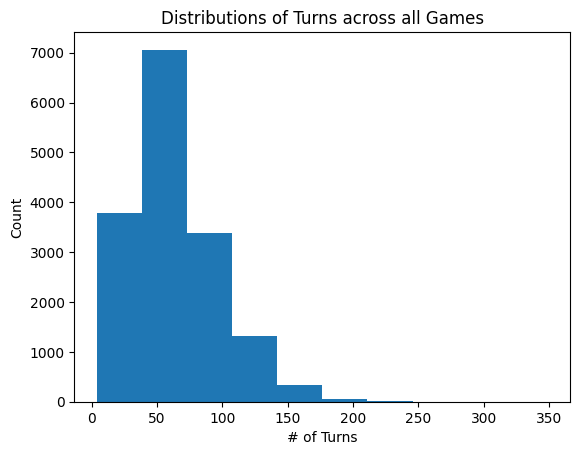

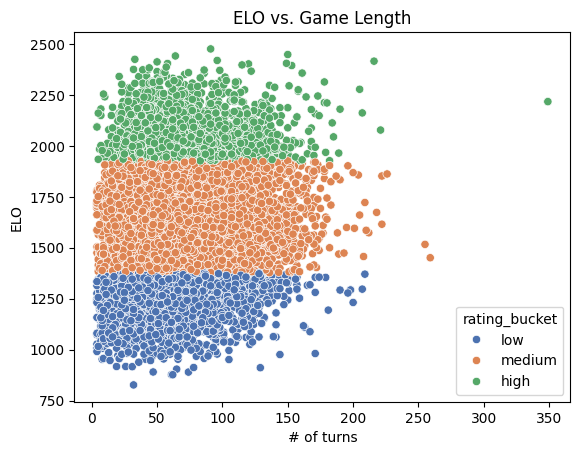

In [8]:
print("Average number of turns")
print(chess_data['turns'].mean())

# Turns visualization overall
plt.hist(chess_data['turns'])
plt.title("Distributions of Turns across all Games")
plt.xlabel("# of Turns")
plt.ylabel("Count")
plt.show()

# Turns by ELO
sns.scatterplot(x=chess_data["turns"], y=chess_data["game_rating"], hue=chess_data["rating_bucket"], palette="deep")
plt.title("ELO vs. Game Length")
plt.xlabel("# of turns")
plt.ylabel("ELO")
plt.show()

#### 6.2. Chess Board Analysis

The goal of this chess board analysis was to draw conclusions about chess strategy and generally how the game is played at different skill levels. The figures and stats generated below give interesting insights into this research goal.

##### Methods

The main analysis done for this milestone was piece movement analysis. Heatmaps were generated from this movement data. These heatmaps were created by making moves on a virtual chess board through python-chess (an open source python chess library). Each time a piece was moved to a square, that square received +1 moves. This was visually displayed as a heatmap that clearly shows trends. These heatmaps were split up into opening (the first few moves of the game), mid-game, and end-game (starts around move 30 and goes until the end). The goal was to provide a clear sense of how pieces tended to move at each stage of the game.

The results showed that the middle squares were always hotly contested, which made another question pop up: "Does taking control of the middle result in higher win rates?". This was studied by counting the number of center moves made by each player (black and white) and comparing that to victory data.

##### Results

The results show that throughout the game, the center squares are always hotly contested. I.e. they get moved to a lot. This happens at all skill levels (high-low ELO). This result is to be expected. One of the main strategies in chess is to control the center of the board. The results shows that when players move to the center of the board more often, they are (on average) slightly more likely to win. This is seen in the positive correlation between number of center moves and win outcome (correlation of 0.16).

Another intresting observation is that the beginning of the game is heavily focused on taking control of the center (and each diagonal square to the center). But after this, the midgame diffuses outward. As pieces develop (such as a bishop or the queen coming out), different squares get more contested. The is amplified in the end-game when the center is still of high importance, but all the other squares still receive a lot of action. Throughout all games, it is clear that the corners of the board are not particularly interesting squares. They do not see a lot of action. This might suggest that it is usually disadvantageous to be on the corners.

Overall, these preliminary results suggest that the center of the chess board is indeed very important. This large dataset provided clear evidence that controling the center is not only the standard strategy, but that it tends to work.

##### Code and Figures


13532


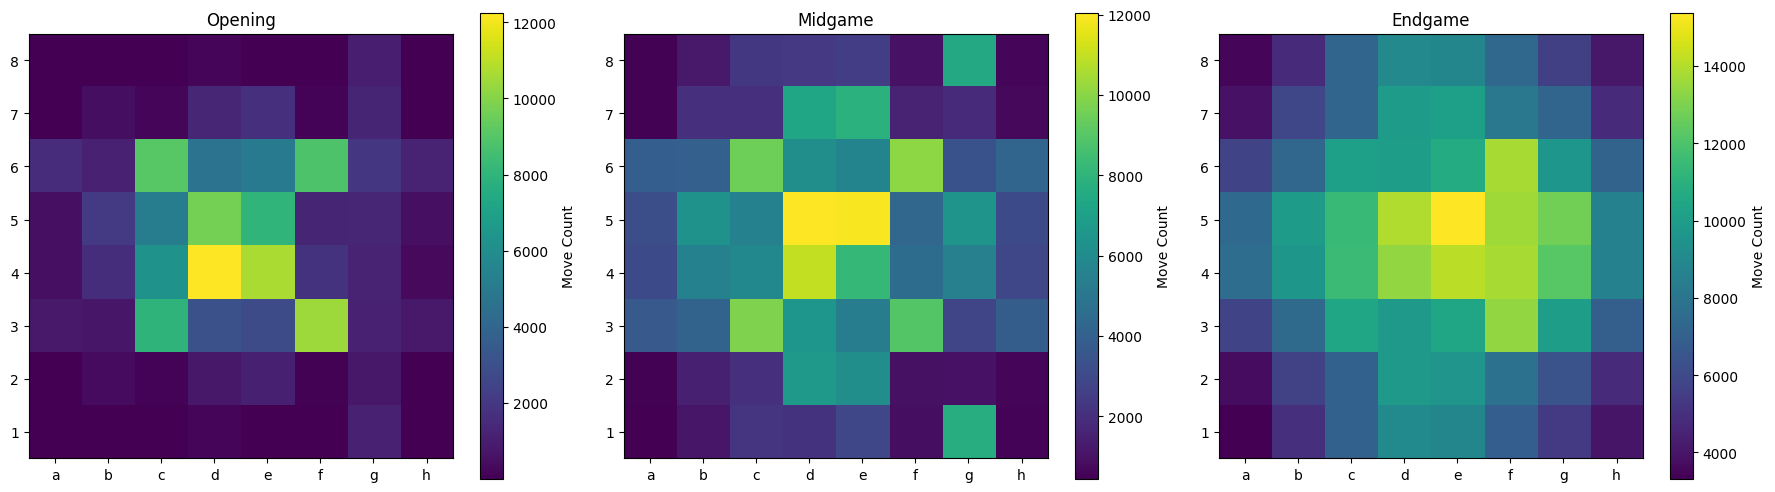

In [9]:
# Chess board heatmap. This function adds to a heatmap given a moveset and board.
def iterate_heatmap_from_moves(moves, board, heatmap):
    for san in moves:
        try:
            move = board.parse_san(san)
        except:
            break  # skip invalid games
        
        square = move.to_square
        
        # Convert square index → row, col
        row = 7 - chess.square_rank(square)
        col = chess.square_file(square)
        
        heatmap[row, col] += 1

        board.push(move)

# Grab games that are long enough to analyze
board_chess_games = chess_data[chess_data["turns"] > 30]
print(len(board_chess_games))

# 8x8 board (rank 8 at top, rank 1 at bottom)
opening_heatmap = np.zeros((8, 8))
mid_game_heatmap = np.zeros((8, 8))
end_game_heatmap = np.zeros((8, 8))

# Count moves for each square
for moves in board_chess_games["moves"]:
    board = chess.Board()

    opening = moves[:10]
    mid_game = moves[10:30]
    end_game = moves[30:]

    iterate_heatmap_from_moves(opening, board, opening_heatmap)
    iterate_heatmap_from_moves(mid_game, board, mid_game_heatmap)
    iterate_heatmap_from_moves(end_game, board, end_game_heatmap)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

heatmaps = [opening_heatmap, mid_game_heatmap, end_game_heatmap]
titles = ["Opening", "Midgame", "Endgame"]

for ax, data, title in zip(axes, heatmaps, titles):
    im = ax.imshow(data)  # no shared vmin/vmax → independent scaling
    
    ax.set_xticks(range(8))
    ax.set_xticklabels(['a','b','c','d','e','f','g','h'])
    
    ax.set_yticks(range(8))
    ax.set_yticklabels(['8','7','6','5','4','3','2','1'])
    
    ax.set_title(title)
    
    # Individual colorbar per subplot
    plt.colorbar(im, ax=ax, label="Move Count")

plt.tight_layout()
plt.show()

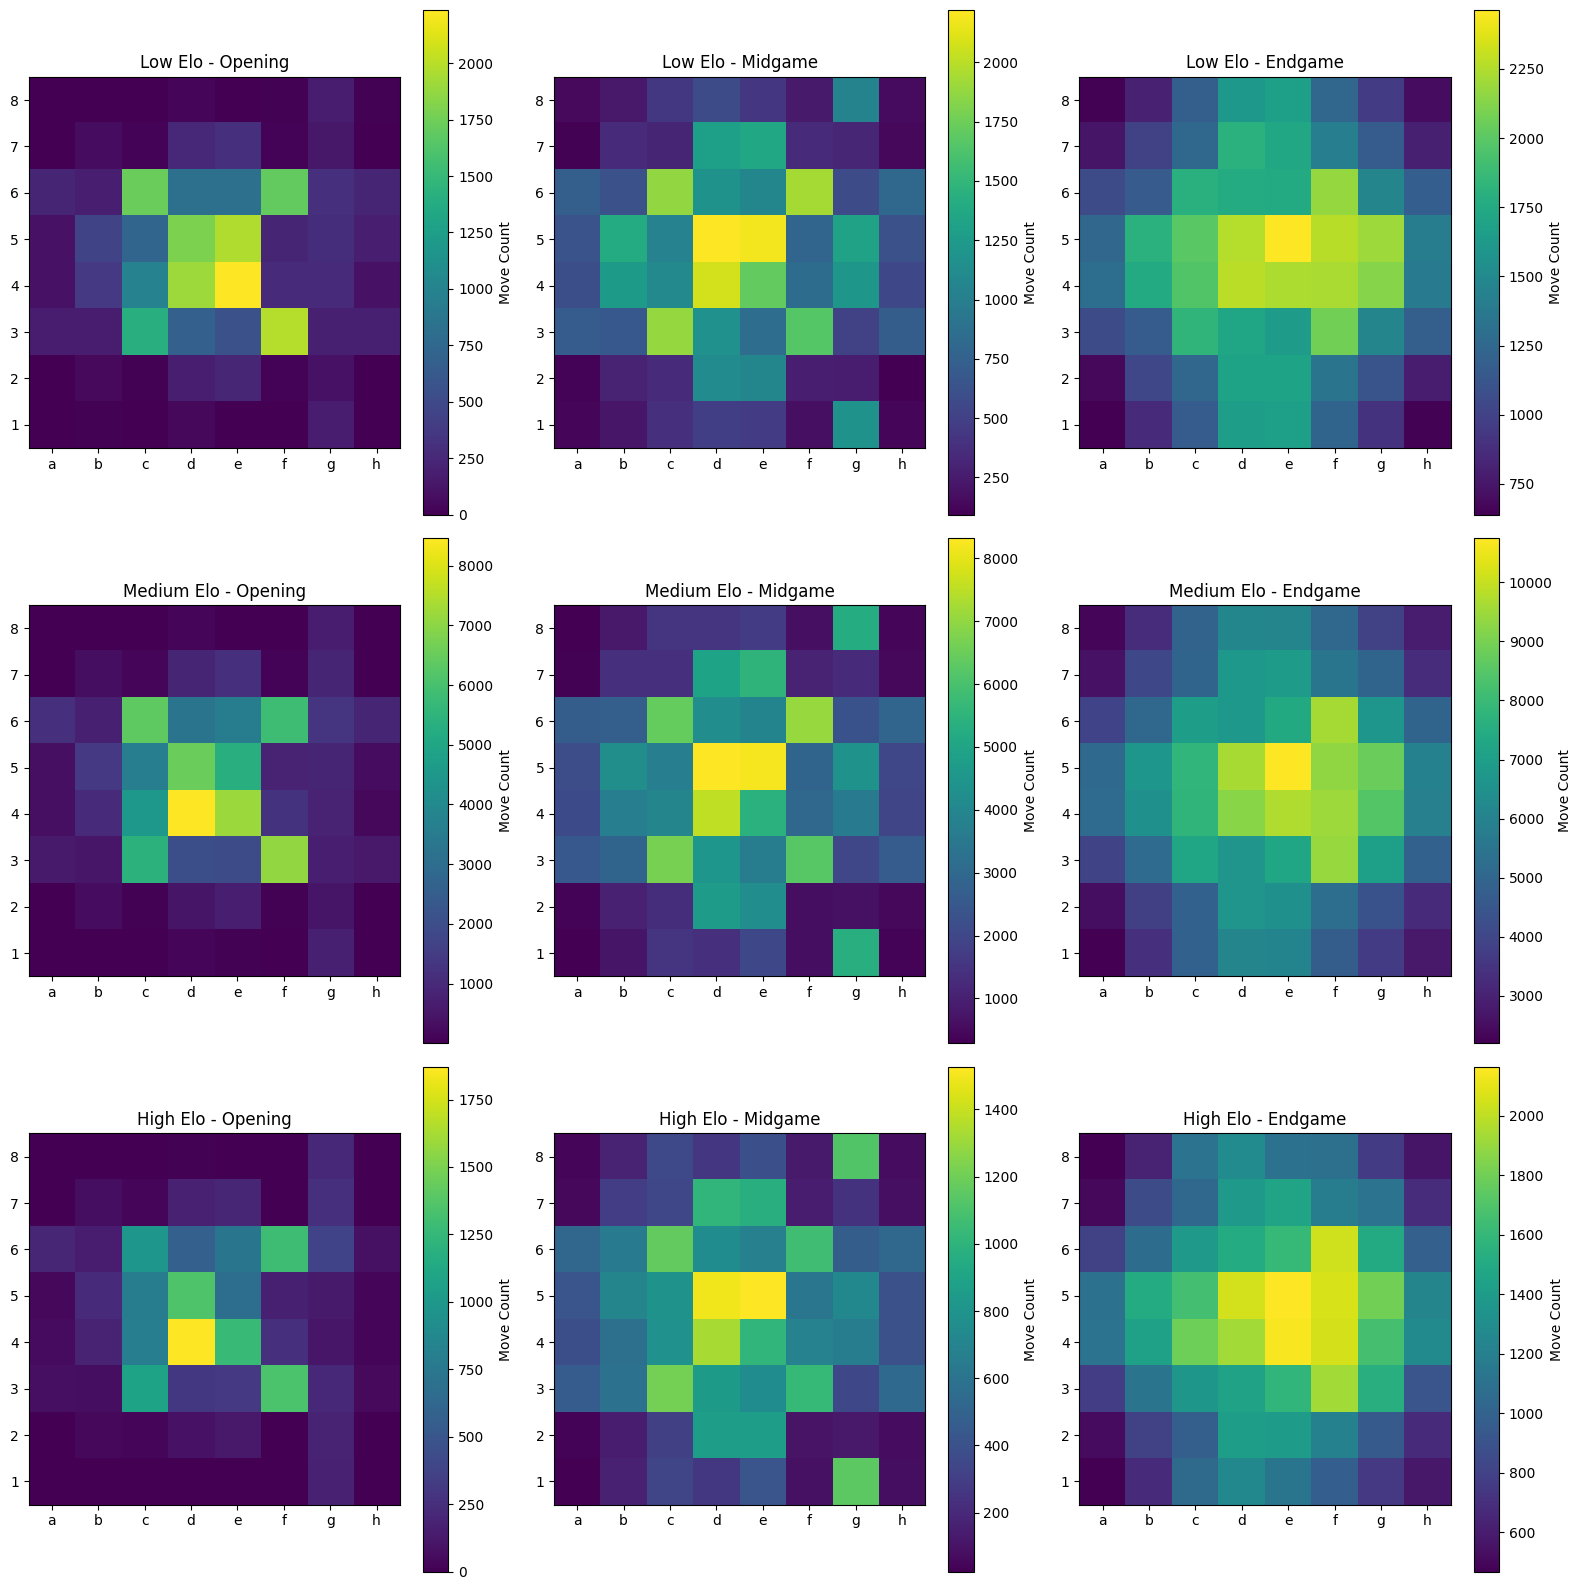

In [10]:
# This block plots a 3x3 grid displaying heatmaps of moves for gamestages and ELO ratings
# Elo buckets and game phases
buckets = ["low", "medium", "high"]
phases = ["Opening", "Midgame", "Endgame"]

# Store heatmaps for each bucket
all_heatmaps = {}

for bucket in buckets:
    opening_heatmap = np.zeros((8, 8))
    mid_game_heatmap = np.zeros((8, 8))
    end_game_heatmap = np.zeros((8, 8))
    
    bucket_games = board_chess_games[board_chess_games["rating_bucket"] == bucket]
    
    for moves in bucket_games["moves"]:
        board = chess.Board()

        opening = moves[:10]
        mid_game = moves[10:30]
        end_game = moves[30:]

        iterate_heatmap_from_moves(opening, board, opening_heatmap)
        iterate_heatmap_from_moves(mid_game, board, mid_game_heatmap)
        iterate_heatmap_from_moves(end_game, board, end_game_heatmap)
    
    all_heatmaps[bucket] = [opening_heatmap, mid_game_heatmap, end_game_heatmap]

# Plot 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(16, 16))

for row, bucket in enumerate(buckets):
    for col, phase in enumerate(phases):
        ax = axes[row, col]
        data = all_heatmaps[bucket][col]
        
        im = ax.imshow(data)
        
        ax.set_xticks(range(8))
        ax.set_xticklabels(['a','b','c','d','e','f','g','h'])
        ax.set_yticks(range(8))
        ax.set_yticklabels(['8','7','6','5','4','3','2','1'])
        
        ax.set_title(f"{bucket.capitalize()} Elo - {phase}")
        
        plt.colorbar(im, ax=ax, label="Move Count")

plt.tight_layout()
plt.show()

In [11]:
# This code block outputs the most contested and least contested squares for each ELO and phase of the game
# Convert to board label
def idx_to_square(row, col):
    file = ['a','b','c','d','e','f','g','h'][col]
    rank = ['8','7','6','5','4','3','2','1'][row]
    return f"{file}{rank}"

# Describe board status at each game state for each ELO group
for bucket in ["low", "medium", "high"]:
    print(f"\n=== {bucket.upper()} ELO ===")
    
    heatmaps = all_heatmaps[bucket]
    phase_names = ["Opening", "Midgame", "Endgame"]
    
    for phase_name, heatmap in zip(phase_names, heatmaps):
        
        # Most contested
        max_idx = np.unravel_index(np.argmax(heatmap), heatmap.shape)
        max_square = idx_to_square(*max_idx)
        max_value = heatmap[max_idx]
        
        # Least contested
        min_idx = np.unravel_index(np.argmin(heatmap), heatmap.shape)
        min_square = idx_to_square(*min_idx)
        min_value = heatmap[min_idx]
        
        print(f"\n{phase_name}:")
        print(f"  Most contested: {max_square} ({max_value})")
        print(f"  Least contested: {min_square} ({min_value})")


=== LOW ELO ===

Opening:
  Most contested: e4 (2235.0)
  Least contested: a8 (0.0)

Midgame:
  Most contested: d5 (2221.0)
  Least contested: h2 (92.0)

Endgame:
  Most contested: e5 (2463.0)
  Least contested: a1 (638.0)

=== MEDIUM ELO ===

Opening:
  Most contested: d4 (8457.0)
  Least contested: a8 (1.0)

Midgame:
  Most contested: d5 (8319.0)
  Least contested: a1 (288.0)

Endgame:
  Most contested: e5 (10741.0)
  Least contested: a1 (2202.0)

=== HIGH ELO ===

Opening:
  Most contested: d4 (1872.0)
  Least contested: a8 (0.0)

Midgame:
  Most contested: e5 (1527.0)
  Least contested: a1 (25.0)

Endgame:
  Most contested: e5 (2164.0)
  Least contested: a8 (469.0)


In [12]:
# Center 16 Squares
# center_squares = {
#     chess.C3, chess.D3, chess.E3, chess.F3,
#     chess.C4, chess.D4, chess.E4, chess.F4,
#     chess.C5, chess.D5, chess.E5, chess.F5,
#     chess.C6, chess.D6, chess.E6, chess.F6
# }

# This code finds the number of center square moves for each player
# Center 4 Squares
center_squares = {
    chess.D4, chess.E4,
    chess.D5, chess.E5
}

def count_center_moves(moves):
    board = chess.Board()
    
    white_count = 0
    black_count = 0
    
    for move in moves:
        move_obj = board.parse_san(move)  # assumes SAN format like "e4", "Nf3"
        
        # Check destination square
        if move_obj.to_square in center_squares:
            if board.turn == chess.WHITE:
                white_count += 1
            else:
                black_count += 1
        
        board.push(move_obj)
    
    return white_count, black_count

# Apply row-wise and expand into two columns
board_chess_games[["white_center_moves", "black_center_moves"]] = (
    board_chess_games["moves"]
    .apply(lambda moves: pd.Series(count_center_moves(moves)))
)

/var/folders/ht/hl9jgtyx3r1fspmzcfk8j4d00000gn/T/ipykernel_33723/414625595.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  board_chess_games[["white_center_moves", "black_center_moves"]] = (
/var/folders/ht/hl9jgtyx3r1fspmzcfk8j4d00000gn/T/ipykernel_33723/414625595.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  board_chess_games[["white_center_moves", "black_center_moves"]] = (


In [13]:
# Describe center moves

# Finding the center move difference allows us to find correlation
# - A pos (+) value means white made more center moves
# - A neg (-) value means black made more center moves
board_chess_games["center_move_difference"] = board_chess_games["white_center_moves"] - board_chess_games["black_center_moves"]
print(board_chess_games.groupby("rating_bucket")["white_center_moves"].mean())
print(board_chess_games.groupby("rating_bucket")["black_center_moves"].mean())
print(board_chess_games["black_center_moves"].mean())

# Find the correlation between center moves and winner
board_chess_games["center_move_difference"].corr(board_chess_games["winner"])

rating_bucket
low       5.161354
medium    5.461655
high      5.698740
Name: white_center_moves, dtype: float64
rating_bucket
low       4.808737
medium    4.955111
high      5.083047
Name: black_center_moves, dtype: float64
4.944132426840083


/var/folders/ht/hl9jgtyx3r1fspmzcfk8j4d00000gn/T/ipykernel_33723/4223096603.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  board_chess_games["center_move_difference"] = board_chess_games["white_center_moves"] - board_chess_games["black_center_moves"]
/var/folders/ht/hl9jgtyx3r1fspmzcfk8j4d00000gn/T/ipykernel_33723/4223096603.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(board_chess_games.groupby("rating_bucket")["white_center_moves"].mean())
/var/folders/ht/hl9jgtyx3r1fspmzcfk8j4d00000gn/T/ipykernel_33723/4223096603.py:8: FutureWarning: The 

np.float64(0.1657928063977587)

#### 6.3. Piece Analysis

Pieces were analyzed to try to figure out which pieces are of high importance. Chess has a standardized point system for rating pieces, is this system accurate? This section also explores whether differences in player ELO affects which pieces tend to be used.

##### Methods

Game movement data was analyzed using a virtual python-chess board. Moves were made on this board (from the dataset) and if a move was made by a piece, it was added to that game's total. Graphs of these results were generated.

##### Results

The results show that pawns are moved the most out of any piece. This makes sense. Pawns are the most abundant and expendable piece. They are also key in all phases of the game. You use them to take control of the center in the opening, you advanced them to strike enemy weeknesses in the mid-game, and try to get them to the back rank for promotion in the end-game. A suprising result was how little queens were moved. Queens are the most powerful piece and biggest threat to the oponnent. However, they were the second least moved piece (behind the king). This is most likely because there is only one queen. There are multiples of all other pieces, so they will logically be moved more. Breaking the moves down by ELO demonstrated that high level chess does not change the types of pieces you use more often. There was a lot of uniformity in the pieces used between the three levels of ELO. The largest difference was between rook usage. It seems that high level players tend to move the rook more often.

These preliminary results demonstrate the importance of pawns. They were moved the most by every skill level. Additionally, the results demonstrated that higher level players tend to use the rook more often than lower ELO players. This demonstrates that the rook is perhaps a harder piece to master.

##### Code and Figures


In [14]:
# Get copy of dataframe to play with
piece_chess_data = chess_data.copy()

# Count the number of times each piece was moved per game
def count_piece_moves(moves):
    board = chess.Board()

    counts = {
        "white_pawn_moves": 0,
        "white_knight_moves": 0,
        "white_bishop_moves": 0,
        "white_rook_moves": 0,
        "white_queen_moves": 0,
        "white_king_moves": 0,
        "black_pawn_moves": 0,
        "black_knight_moves": 0,
        "black_bishop_moves": 0,
        "black_rook_moves": 0,
        "black_queen_moves": 0,
        "black_king_moves": 0,
    }

    piece_name = {
        chess.PAWN: "pawn",
        chess.KNIGHT: "knight",
        chess.BISHOP: "bishop",
        chess.ROOK: "rook",
        chess.QUEEN: "queen",
        chess.KING: "king",
    }

    # Pass moves into virtual chess board
    for move in moves:
        move_obj = board.parse_san(move)

        moving_piece = board.piece_at(move_obj.from_square)
        if moving_piece is None:
            board.push(move_obj)
            continue

        color = "white" if moving_piece.color == chess.WHITE else "black"
        piece = piece_name[moving_piece.piece_type]

        counts[f"{color}_{piece}_moves"] += 1

        board.push(move_obj)

    return pd.Series(counts)

In [15]:
piece_move_counts = piece_chess_data["moves"].apply(count_piece_moves)
piece_chess_data = pd.concat([piece_chess_data, piece_move_counts], axis=1)

In [16]:
# Summary of moves
combined = {
    "pawn": piece_chess_data["white_pawn_moves"].sum() + piece_chess_data["black_pawn_moves"].sum(),
    "knight": piece_chess_data["white_knight_moves"].sum() + piece_chess_data["black_knight_moves"].sum(),
    "bishop": piece_chess_data["white_bishop_moves"].sum() + piece_chess_data["black_bishop_moves"].sum(),
    "rook": piece_chess_data["white_rook_moves"].sum() + piece_chess_data["black_rook_moves"].sum(),
    "queen": piece_chess_data["white_queen_moves"].sum() + piece_chess_data["black_queen_moves"].sum(),
    "king": piece_chess_data["white_king_moves"].sum() + piece_chess_data["black_king_moves"].sum(),
}

combined_series = pd.Series(combined).sort_values(ascending=False)
print(combined_series)

pawn      275340
knight    175196
bishop    154239
rook      138541
king      131836
queen     125379
dtype: int64


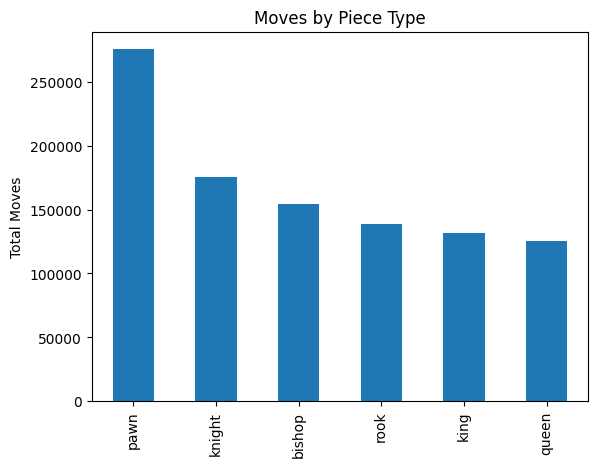

In [17]:
# Plot moves by every piece
combined_series.plot(kind="bar")
plt.ylabel("Total Moves")
plt.title("Moves by Piece Type")
plt.show()

/var/folders/ht/hl9jgtyx3r1fspmzcfk8j4d00000gn/T/ipykernel_33723/2953767315.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = combined_df.groupby(piece_chess_data["rating_bucket"]).sum()


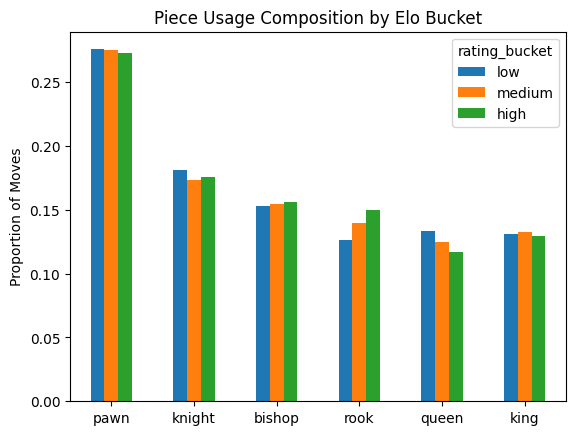

In [18]:
# Plot moves by ELO and pieces
combined_df = pd.DataFrame({
    "pawn": piece_chess_data["white_pawn_moves"] + piece_chess_data["black_pawn_moves"],
    "knight": piece_chess_data["white_knight_moves"] + piece_chess_data["black_knight_moves"],
    "bishop": piece_chess_data["white_bishop_moves"] + piece_chess_data["black_bishop_moves"],
    "rook": piece_chess_data["white_rook_moves"] + piece_chess_data["black_rook_moves"],
    "queen": piece_chess_data["white_queen_moves"] + piece_chess_data["black_queen_moves"],
    "king": piece_chess_data["white_king_moves"] + piece_chess_data["black_king_moves"],
})

grouped = combined_df.groupby(piece_chess_data["rating_bucket"]).sum()
normalized = grouped.div(grouped.sum(axis=1), axis=0)
plot_data = normalized.T
plot_data.plot(kind="bar")

plt.ylabel("Proportion of Moves")
plt.title("Piece Usage Composition by Elo Bucket")
plt.xticks(rotation=0)
plt.show()

## 7. Data Processing/Analysis Methodology


#### Board Chess Engine


In [19]:
# -------------------------------------------------------
# Use Python Chess to get parameters for neural net
# -------------------------------------------------------


def board_analysis(movelist):
    piece_lookup = {
        chess.PAWN: "pawn",
        chess.KNIGHT: "knight",
        chess.BISHOP: "bishop",
        chess.ROOK: "rook",
        chess.QUEEN: "queen",
        chess.KING: "king",
    }
    piece_values = {
        chess.PAWN: 1,
        chess.KNIGHT: 3,
        chess.BISHOP: 3,
        chess.ROOK: 5,
        chess.QUEEN: 9,
        chess.KING: 0,
    }
    colors = ["white", "black"]
    categories = [
        "moves",
        "captures",
        "checks",
        "forks",
        "pins",
        "attacks",
        "defenses",
        "center_control_turns",
    ]
    pieces = ["pawn", "knight", "bishop", "rook", "queen", "king"]
    center_squares = [chess.D4, chess.E4, chess.D5, chess.E5]

    analysis = {
        color: {
            category: {piece: 0 for piece in pieces}
            for category in categories
        }
        for color in colors
    }
    promotion_counts = {color: 0 for color in colors}
    forced_move_counts = {color: 0 for color in colors}
    material_taken = {color: 0 for color in colors}
    material_lost = {color: 0 for color in colors}

    board = chess.Board()

    for san in movelist:
        try:
            move = board.parse_san(san)
        except Exception:
            break

        color = "white" if board.turn == chess.WHITE else "black"
        opponent_color = "black" if color == "white" else "white"
        piece = board.piece_at(move.from_square)

        if piece is None:
            break

        piece_name = piece_lookup[piece.piece_type]
        analysis[color]["moves"][piece_name] += 1

        captured_value = 0
        if board.is_capture(move):
            analysis[color]["captures"][piece_name] += 1
            if board.is_en_passant(move):
                captured_value = piece_values[chess.PAWN]
            else:
                captured_piece = board.piece_at(move.to_square)
                if captured_piece is not None:
                    captured_value = piece_values[captured_piece.piece_type]

        material_taken[color] += captured_value
        material_lost[opponent_color] += captured_value

        board.push(move)

        if board.is_check():
            analysis[color]["checks"][piece_name] += 1

        attacked_enemy_pieces = 0
        defended_friendly_pieces = 0
        pinned_enemy_pieces = 0
        for square in board.attacks(move.to_square):
            target_piece = board.piece_at(square)
            if target_piece is None:
                continue
            if target_piece.color != piece.color:
                attacked_enemy_pieces += 1
                if board.is_pinned(target_piece.color, square):
                    pinned_enemy_pieces += 1
            else:
                defended_friendly_pieces += 1

        analysis[color]["attacks"][piece_name] += attacked_enemy_pieces
        analysis[color]["defenses"][piece_name] += defended_friendly_pieces

        if attacked_enemy_pieces >= 2:
            analysis[color]["forks"][piece_name] += 1

        if pinned_enemy_pieces > 0:
            analysis[color]["pins"][piece_name] += pinned_enemy_pieces

        if move.promotion is not None:
            promotion_counts[color] += 1

        if board.legal_moves.count() == 1:
            forced_move_counts[color] += 1

        for square in center_squares:
            center_piece = board.piece_at(square)
            if center_piece is None:
                continue
            center_color = "white" if center_piece.color == chess.WHITE else "black"
            center_piece_name = piece_lookup[center_piece.piece_type]
            analysis[center_color]["center_control_turns"][center_piece_name] += 1

    flattened_vector = []
    for color in colors:
        for category in categories:
            for piece in pieces:
                flattened_vector.append(analysis[color][category][piece])

    for color in colors:
        flattened_vector.extend([
            promotion_counts[color],
            forced_move_counts[color],
            material_taken[color],
            material_lost[color],
        ])

    return flattened_vector


In [20]:
colors = ["white", "black"]
categories = [
    "moves",
    "captures",
    "checks",
    "forks",
    "pins",
    "attacks",
    "defenses",
    "center_control_turns",
]
pieces = ["pawn", "knight", "bishop", "rook", "queen", "king"]
summary_metrics = ["promotions", "forced_moves", "material_taken", "material_lost"]

neural_net_columns = [
    f"{color}_{category}_{piece}"
    for color in colors
    for category in categories
    for piece in pieces
] + [
    f"{color}_{metric}"
    for color in colors
    for metric in summary_metrics
]

neural_net_columns += [
    "white_elo",
    "black_elo",
    "winner",
    "total_turns",
    "white_turns",
    "black_turns",
    "idx"
]

neural_net_rows = []

for idx, row in chess_data.iterrows():
    total_turns = row["turns"]
    white_turns = (total_turns + 1) // 2
    black_turns = total_turns // 2

    board_analysis_row = board_analysis(row["moves"])
    board_analysis_row += [
        row["white_rating"],
        row["black_rating"],
        row["winner"],
        total_turns,
        white_turns,
        black_turns,
        idx
    ]
    neural_net_rows.append(board_analysis_row)

board_analysis_results = pd.DataFrame(neural_net_rows, columns=neural_net_columns)
board_analysis_results = board_analysis_results.set_index('idx').sort_index()
board_analysis_results.describe()


,white_moves_pawn,white_moves_knight,white_moves_bishop,white_moves_rook,white_moves_queen,white_moves_king,white_captures_pawn,white_captures_knight,white_captures_bishop,white_captures_rook,...,black_promotions,black_forced_moves,black_material_taken,black_material_lost,white_elo,black_elo,winner,total_turns,white_turns,black_turns
count,15943.000000,15943.00000,15943.000000,15943.000000,15943.000000,15943.000000,15943.000000,15943.000000,15943.000000,15943.000000,...,15943.000000,15943.000000,15943.000000,15943.000000,15943.00000,15943.000000,15943.000000,15943.000000,15943.000000,15943.000000
mean,8.607288,5.57831,4.966067,4.442828,4.010977,4.032052,1.841247,1.363984,1.430095,1.172803,...,0.080223,0.353008,20.199272,20.374020,1599.90949,1596.395660,0.041147,62.756758,31.637521,31.119237
std,4.381908,3.43769,3.048665,5.252713,3.749370,5.677335,1.375202,1.241930,1.195479,1.490381,...,0.314457,0.908748,11.310281,11.261918,282.71278,287.500823,0.976612,33.240935,16.615902,16.628786
min,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,784.00000,789.000000,-1.000000,4.000000,2.000000,2.000000
25%,5.000000,3.00000,3.000000,1.000000,2.000000,1.000000,1.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,11.000000,11.000000,1399.00000,1393.000000,-1.000000,39.000000,20.000000,19.000000
50%,8.000000,5.00000,4.000000,3.000000,3.000000,2.000000,2.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,20.000000,20.000000,1579.00000,1576.000000,0.000000,57.000000,29.000000,28.000000
75%,11.000000,7.00000,6.000000,6.000000,5.000000,5.000000,3.000000,2.000000,2.000000,2.000000,...,0.000000,0.000000,29.000000,30.000000,1795.00000,1793.000000,1.000000,81.000000,41.000000,40.000000
max,35.000000,59.00000,44.000000,83.000000,41.000000,74.000000,8.000000,11.000000,11.000000,9.000000,...,5.000000,16.000000,55.000000,55.000000,2622.00000,2588.000000,1.000000,349.000000,175.000000,174.000000


In [21]:
board_analysis_results

,white_moves_pawn,white_moves_knight,white_moves_bishop,white_moves_rook,white_moves_queen,white_moves_king,white_captures_pawn,white_captures_knight,white_captures_bishop,white_captures_rook,...,black_promotions,black_forced_moves,black_material_taken,black_material_lost,white_elo,black_elo,winner,total_turns,white_turns,black_turns
idx,,,,,,,,,,,,,,,,,,,,,
1,6,0,0,0,2,0,2,0,0,0,...,0,0,11,2,1322,1261,-1.0,16,8,8
2,12,3,8,5,3,0,7,1,3,3,...,0,0,7,38,1496,1500,1.0,61,31,30
3,4,9,4,3,10,1,1,3,2,0,...,0,0,8,30,1439,1454,1.0,61,31,30
4,13,8,3,16,4,4,1,3,1,5,...,0,1,30,38,1523,1469,1.0,95,48,47
6,3,4,5,0,4,1,0,2,0,0,...,0,0,9,9,1520,1423,1.0,33,17,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20053,3,4,3,1,0,1,0,1,1,0,...,0,0,4,2,1691,1220,1.0,24,12,12
20054,8,11,3,2,8,9,2,3,0,0,...,0,1,26,25,1233,1196,-1.0,82,41,41
20055,3,6,5,0,4,0,0,0,2,0,...,0,0,6,4,1219,1286,1.0,35,18,17


#### Stockfish Analysis


In [22]:
# Worker Function
STOCKFISH_PATH = "/opt/homebrew/bin/stockfish"
DEPTH = 12 # ~1hr for whole dataset
TIME = 0.001 # ~15min for whole dataset

def evaluate_moves(chunk):
    results = []

    with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
        engine.configure({"Threads": 2, "Hash": 256})

        for i, moves in chunk:
            board = chess.Board()
            centipawn = []

            for m in moves:
                info = engine.analyse(board, chess.engine.Limit(time=TIME))
                # Elements 0, 2, 4, ... are white perspective
                # Elements 1, 3, 5, ... are black perspective
                score = info["score"].relative

                if score.is_mate():
                    cp = 100000 if score.mate() > 0 else -100000
                else:
                    cp = score.score()

                centipawn.append(cp)
                board.push_san(m)

            results.append((i, centipawn))

    return results

# Chunking Function
def make_indexed_chunks(df, n_chunks):
    chunks = np.array_split(df, n_chunks)
    return [
        [(idx, row["moves"]) for idx, row in chunk.iterrows()]
        for chunk in chunks
    ]

In [23]:
n_workers = 4
chunks = make_indexed_chunks(chess_data, n_workers)
ctx = mp.get_context("spawn")

for run in range(5):
    continue
    results = Pool(2).map(evaluate_moves, chunks)

    out_data = pd.DataFrame(
        [item for chunk in results for item in chunk],
        columns=["index", "centipawn"]
    )

    out_data = out_data.set_index("index").sort_index()
    out_data.to_csv("centipawn_data_run_"+str(run)+".csv")
    print(str(run) +  " Complete")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:54: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [24]:
# Assign centipawn post-processing
cp = pd.DataFrame()
for r in range (5):
    cp_raw = pd.read_csv("centipawn/centipawn_data_run_"+str(r)+".csv")
    if r == 0: cp['index'] = cp_raw['index']
    cp[str(r)] = cp_raw['centipawn'].apply(lambda row: [int(value.strip()) for value in row.strip('[]').split(',')])
cp = cp.set_index('index').sort_index()
cp['average'] = cp[['0','1','2','3','4']].apply(lambda row: np.mean(np.array(row.tolist()),axis=0).astype(int),axis=1)
chess_data['centipawn'] = cp['average']
# Separate black/white
chess_data['centipawn_white'] = cp['average'].apply(lambda x: x[::2])
chess_data['centipawn_black'] = cp['average'].apply(lambda x: x[1::2])
chess_data['centipawn_white_avg'] = chess_data['centipawn_white'].apply(lambda row: np.mean(row))
chess_data['centipawn_black_avg'] = chess_data['centipawn_black'].apply(lambda row: np.mean(row))
chess_data['centipawn_avg'] = (chess_data['centipawn_white_avg'] + chess_data['centipawn_black_avg']) /2

# Opening standardization
print(len(chess_data))
chess_data['opening_aggro'] = chess_data['opening_eco'].str[0].map({'A':4,'B':1,'C':3,'D':5,'E':2})
chess_data['opening_skill'] = chess_data['opening_eco'].str[0].map({'A':5,'B':1,'C':3,'D':4,'E':2})
chess_data['opening_diff'] = chess_data['opening_eco'].str[0].map({'A':2,'B':5,'C':3,'D':1,'E':4})

15943


In [25]:
new_results = board_analysis_results.drop(columns=['winner','total_turns','white_elo','black_elo'])
chess_data = pd.concat([chess_data, new_results], axis=1)
chess_data.head()


,turns,victory_status,winner,increment_code,white_rating,black_rating,moves,opening_eco,opening_name,opening_ply,...,white_promotions,white_forced_moves,white_material_taken,white_material_lost,black_promotions,black_forced_moves,black_material_taken,black_material_lost,white_turns,black_turns
1,16,0,-1.0,5+10,1322,1261,"[d4, Nc6, e4, e5, f4, f6, dxe5, fxe5, fxe5, Nx...",B00,Nimzowitsch Defense: Kennedy Variation,4,...,0,0,2,11,0,0,11,2,8,8
2,61,1,1.0,5+10,1496,1500,"[e4, e5, d3, d6, Be3, c6, Be2, b5, Nd2, a5, a4...",C20,King's Pawn Game: Leonardis Variation,3,...,0,1,38,7,0,0,7,38,31,30
3,61,1,1.0,20+0,1439,1454,"[d4, d5, Nf3, Bf5, Nc3, Nf6, Bf4, Ng4, e3, Nc6...",D02,Queen's Pawn Game: Zukertort Variation,3,...,0,7,30,8,0,0,8,30,31,30
4,95,1,1.0,30+3,1523,1469,"[e4, e5, Nf3, d6, d4, Nc6, d5, Nb4, a3, Na6, N...",C41,Philidor Defense,5,...,1,0,38,30,0,1,30,38,48,47
6,33,0,1.0,10+0,1520,1423,"[d4, d5, e4, dxe4, Nc3, Nf6, f3, exf3, Nxf3, N...",D00,Blackmar-Diemer Gambit: Pietrowsky Defense,10,...,0,1,9,9,0,0,9,9,17,16


## 8. Answering Question 1

### Can we utilize patterns in the data to differentiate between the gameplay style of experienced players vs inexperienced players?


/var/folders/ht/hl9jgtyx3r1fspmzcfk8j4d00000gn/T/ipykernel_33723/1689474211.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plt.plot(chess_data.groupby('rating_bucket')['centipawn_avg'].mean())


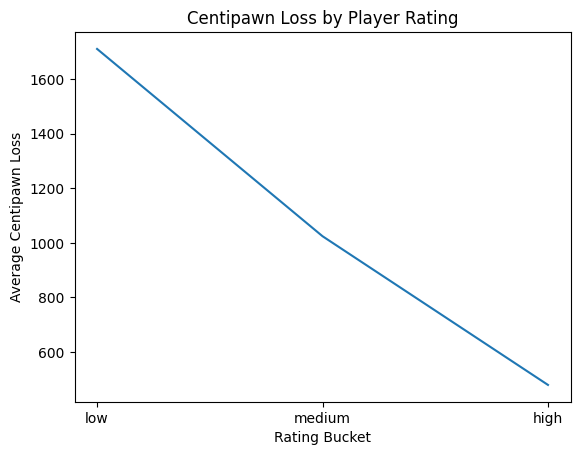

In [26]:
plt.plot(chess_data.groupby('rating_bucket')['centipawn_avg'].mean())
plt.title('Centipawn Loss by Player Rating')
plt.xlabel('Rating Bucket')
plt.ylabel('Average Centipawn Loss')
plt.show()

Aftetr running centipawn loss analysis on the list of moves in each game, the average centipawn loss of each game was taken. These values were then averaged according to the three rating brackets of low, medium, and high ELO players. The graph above reveals that the average centipawn loss of each game appears to drop as the player rating increases. This intuitively makes sense, as magnitudes of centipawn loss represent large successes or failures per move in a game. Lower level players may be more susceptible to making detrimental mistakes, whereas higher level players may be more aware of similar mistakes. This pertains even if the moves appear more risky, as a more thought-out strategy may require seemingly disastrous moves, making their actual centipawn loss less extreme.


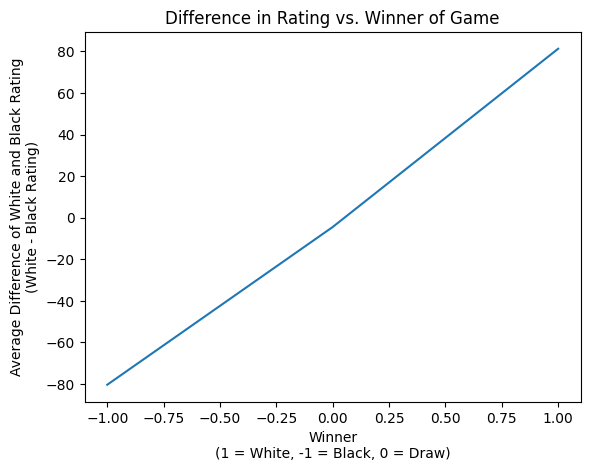

In [41]:
plt.plot((chess_data['white_rating'] - chess_data['black_rating']).groupby(chess_data['winner']).mean())
plt.title('Difference in Rating vs. Winner of Game')
plt.xlabel('Winner\n(1 = White, -1 = Black, 0 = Draw)')
plt.ylabel('Average Difference of White and Black Rating\n(White - Black Rating)')
plt.show()

The figure shown above demonstrates the average difference in rating between the white and black players of a game plotted against the winner of said game. This graph implies that, on average, the winners of a game are typically ~80 ELO higher than their opponents, whether that be white or black. And for games that end in draws, both players are more equivalent in their ratings. This finding makes logical sense, as the victor of a game would be assumed to be "better" than the opponent in some way. However, using averages only in this graph enforces limitations on the applicability for the full range of chess games in the dataset. Interpret graph with caution before making assumptions.


In [27]:
# Linear Regression Model
def linearModel(df,ins,outs):
    inputs = ''
    for i in ins:
        inputs += i + ' + '
    inputs = inputs[0:len(inputs)-3]
    model = sm.ols(formula=f"{outs} ~ {inputs}", data=df).fit()
    mse = mean_squared_error(df[outs], model.predict(df))
    print(f'Linear model predicting: {outs}')
    print(f'MSE: {mse}')
    print(f'R^2: {model.rsquared}')
    #display(model.summary())

# Ridge or Lasso Regression Model
def runModel(df,ins,outs,m):
    train_set,test_set = train_test_split(df, test_size=0.2, random_state=1)
    x_train = StandardScaler().fit_transform(train_set[ins])
    x_test = StandardScaler().fit_transform(test_set[ins])
    y_train = train_set[outs]
    y_test = test_set[outs]
    lam = np.logspace(-10,5,20)
    mse = []
    for a in lam:
        if m == 'ridge':
            model = Ridge(alpha=a).fit(x_train,y_train)
            mse.append(mean_squared_error(y_test, model.predict(x_test)))
        if m == 'lasso':
            model = Lasso(alpha=a).fit(x_train,y_train)
            mse.append(mean_squared_error(y_test, model.predict(x_test)))

    print(f'Optimal Lamda Value: {lam[mse.index(min(mse))]}')
    plt.plot(lam,mse)
    plt.title(f'{m} regression model predicting {outs}')
    plt.ylabel('Mean Squared Error (MSE)')
    plt.xlabel('Lambda Value')
    plt.show()

In [28]:
ins = list(chess_data.iloc[:, 19:].columns)
ins.append('turns')
ins.append('game_rating')
outs = 'centipawn_avg'
linearModel(chess_data,ins,outs)

Linear model predicting: centipawn_avg
MSE: 2843537.3712902586
R^2: 0.16805731760583542


By compiling board analyses data, opening data, player ratings, and game length, the linear regression model was not able to accurately predict the average centipawn loss value of a game of chess. The R^2 value is too low and the MSE is critically high. This finding shows that centipawn loss may not be directly linearly correlated with the player ratings or what specific strategies they use. Instead, a deeper connection between the parameters may exist that cannot be fully encapsulated by simple linear regression.


Optimal Lamda Value: 428.13323987193957


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 6.848437780877451e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


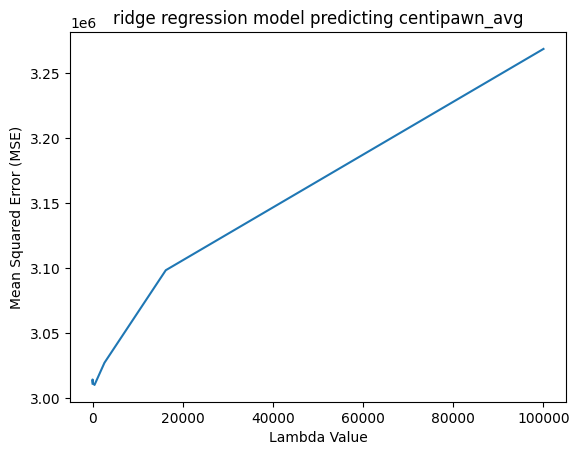

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.826e+10, tolerance: 4.346e+06
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.826e+10, tolerance: 4.346e+06
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iter

Optimal Lamda Value: 1.8329807108324374


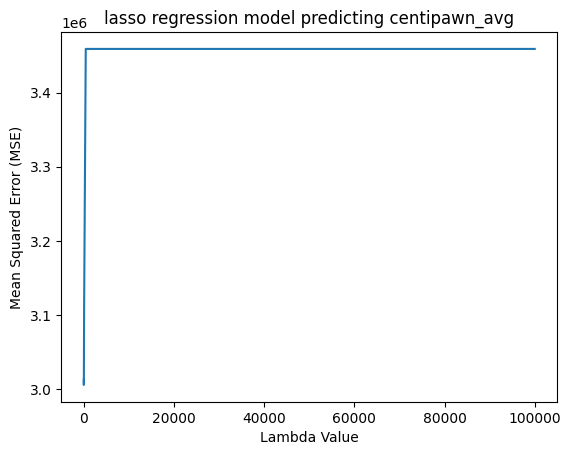

In [43]:
ins = list(chess_data.iloc[:, 19:].columns)
ins.append('turns')
outs = 'centipawn_avg'
runModel(chess_data,ins,outs,'ridge')
runModel(chess_data,ins,outs,'lasso')

The ridge and lasso regressions above concur with the findings of the linear regression model. The MSE of these models is too high to prove viable, and even testing distinct lambda values for the ridge and lasso models proved unhelpful. Average centipawn loss cannot be directly correlated with player ratings or game strategies.


In [45]:
ins = list(chess_data.iloc[:, 16:].columns)
ins.append('turns')
#ins.append('white_rating')
#ins.append('black_rating')
outs = 'winner'
linearModel(chess_data,ins,outs)

Linear model predicting: winner
MSE: 0.27619894797419925
R^2: 0.7103954253911333


The R^2 of the linear regression model for predicting the winner of a game using board analyses data, opening data, centipawn data, and game length, was unexpectedly high at a value of 0.71. While this value is still lower than a viable threshold value, it does indicate that there is some linear correlation between the winner of a game and game strategies or average centipawn loss. This finding makes logical sense, as the more active a player's strategy or the less critical mistakes a player makes, the more likely it is that such a player will win the game. In testing, the addition of player ratings had no effect on the model. This would imply that the patterns of the game are not strictly linearly correlated with the ratings of the players. This means that higher rated players do not necessarily play certain strategies or show certain patterns that lower rater player do not. Such connections cannot be attributed solely to linear regression and require a deeper form of analysis.


Optimal Lamda Value: 11.288378916846883


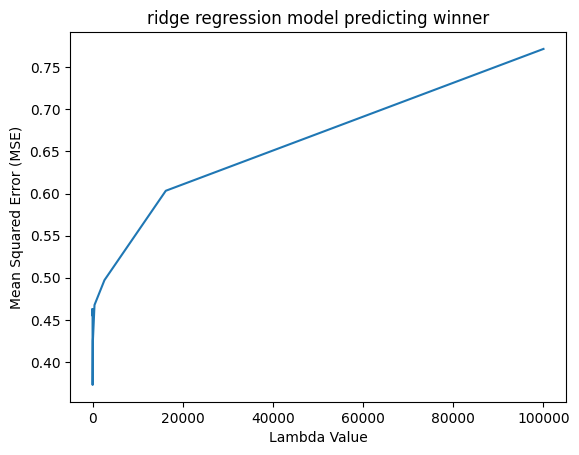

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.822e+03, tolerance: 1.217e+00
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.822e+03, tolerance: 1.217e+00
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iter

Optimal Lamda Value: 0.0012742749857031347


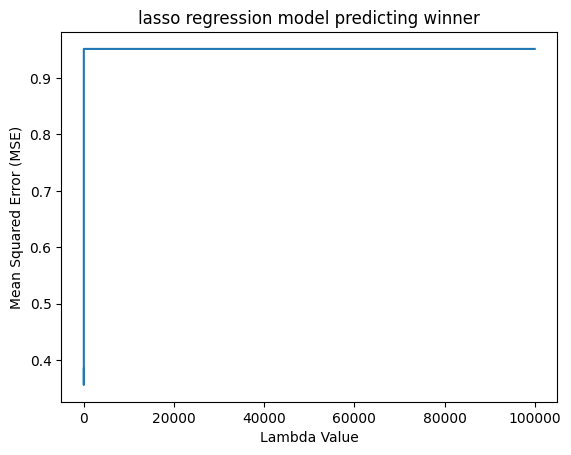

In [31]:
ins = list(chess_data.iloc[:, 16:].columns)
ins.append('turns')
outs = 'winner'
runModel(chess_data,ins,outs,'ridge')
runModel(chess_data,ins,outs,'lasso')

The MSE of the ridge and lasso regression models were in a much more viable scale than the other regression predictions. Both fell within a range of 1, with the best lambda emerging from the ridge regreession at ~11. Through reducing the variance of certain parameters, the linear model was better able to predict the winner of a game in regards to the game strategies played. This provides further relevance to the simple linear model's findings that winner can be estimated through the patterns of gameplay. However, this does not further the claim that such strategies change by rating, as such values were not included in the model for having too little effect.


In [50]:
ins = list(chess_data.iloc[:, 16:].columns)
ins.append('turns')
outs = 'game_rating'
linearModel(chess_data,ins,outs)

Linear model predicting: game_rating
MSE: 54972.62231854843
R^2: 0.21008961921577396


The average rating of a game was also not accurately estimated using a simple linear regression model. Intaking board analyses data, opening data, centipawn data, and game length did not prove viable for estimating player rating. This further supports the previous models' findings that rating is liekly not linearly correlated with game strategies or patterns. The data may be too diverse for such a simple estimation and will require more in-depth analysis for better conclusions.


Optimal Lamda Value: 69.5192796177562


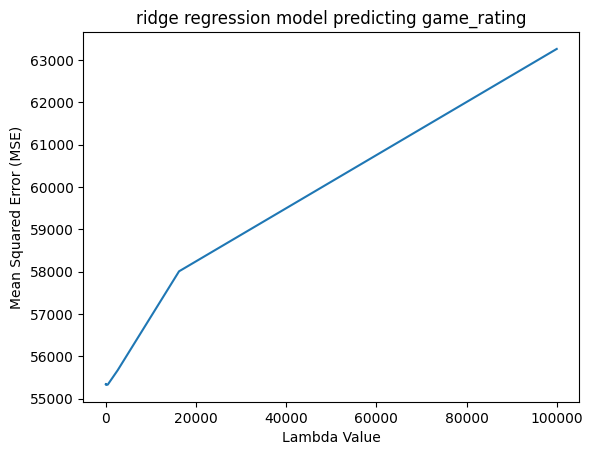

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.509e+08, tolerance: 8.907e+04
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.509e+08, tolerance: 8.907e+04
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iter

Optimal Lamda Value: 0.2976351441631313


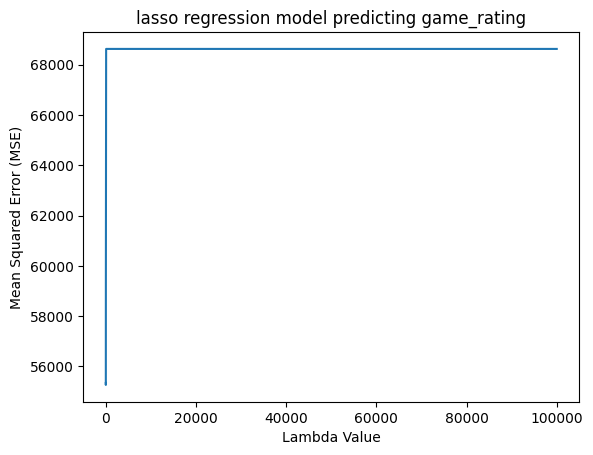

In [33]:
ins = list(chess_data.iloc[:, 16:].columns)
ins.append('turns')
outs = 'game_rating'
runModel(chess_data,ins,outs,'ridge')
runModel(chess_data,ins,outs,'lasso')

Both the ridge and lasso regression models to predict the rating of a game were similarly inefective. The MSE values proved too large for viability. This concludes that simple linear regression models are ineffective at estimating both average centipawn loss and game/player ratings. However, these linear regression models showed promise in estimating the winners of a game. Though, even this showed a relatively unreliable R^2 value of 0.71, indicating that further analysis is needed to to properly correlate game patterns with game winners, and especially for correlating to player ratings.


## 9. Answering Question 2

### What correlations or other predictions can be identified based on game data?


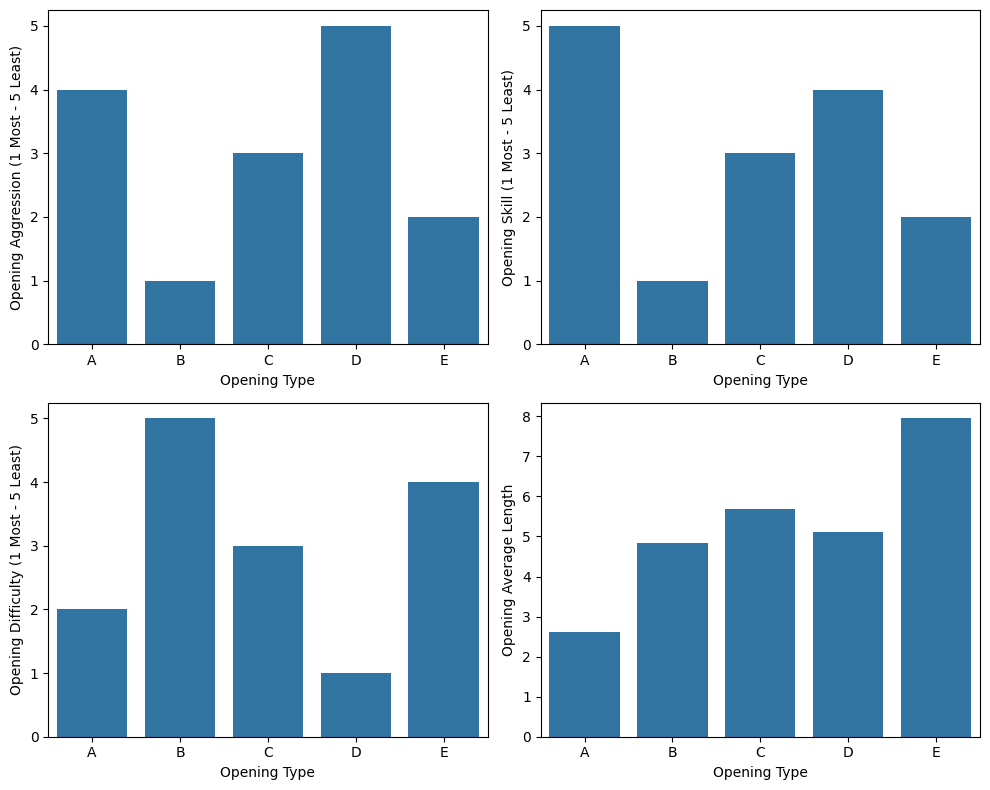

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

sns.barplot(data=chess_data.groupby(chess_data['opening_eco'].str[0])['opening_aggro'].mean(),ax=axes[0,0])
axes[0,0].set_xlabel('Opening Type')
axes[0,0].set_ylabel('Opening Aggression (1 Most - 5 Least)')
sns.barplot(data=chess_data.groupby(chess_data['opening_eco'].str[0])['opening_skill'].mean(),ax=axes[0,1])
axes[0,1].set_xlabel('Opening Type')
axes[0,1].set_ylabel('Opening Skill (1 Most - 5 Least)')
sns.barplot(data=chess_data.groupby(chess_data['opening_eco'].str[0])['opening_diff'].mean(),ax=axes[1,0])
axes[1,0].set_xlabel('Opening Type')
axes[1,0].set_ylabel('Opening Difficulty (1 Most - 5 Least)')
sns.barplot(data=chess_data.groupby(chess_data['opening_eco'].str[0])['opening_ply'].mean(),ax=axes[1,1])
axes[1,1].set_xlabel('Opening Type')
axes[1,1].set_ylabel('Opening Average Length')

plt.tight_layout()
plt.show()


## 10. Answering Question 3

### Can we use machine learning to predict the rating of a player based purely on a list of moves?


## 11. Summary and Conclusions
